# Импорт библиотек

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from decision_tree import CustomDecisionTreeClassifier

In [2]:
RANDOM_STATE = 42

# Обучение

In [3]:
X, y = make_moons(n_samples=1000, noise=0.27, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

In [4]:
models = {
    'Custom (gini)': CustomDecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=5),
    'Custom (chi2)': CustomDecisionTreeClassifier(criterion='chi2', max_depth=5, min_samples_leaf=5),
    'sklearn DT (gini)': DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE),
    'sklearn DT (entropy)': DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5, random_state=RANDOM_STATE),
}

In [5]:
fitted_models = {}
rows = []

for name, model in models.items():
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time_ms = (time.perf_counter() - t0) * 1000

    y_pred = model.predict(X_test)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'fit_time_ms': fit_time_ms,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    })
    fitted_models[name] = model

In [6]:
results = pd.DataFrame(rows).sort_values(by=["accuracy", "f1"], ascending=False).reset_index(drop=True)

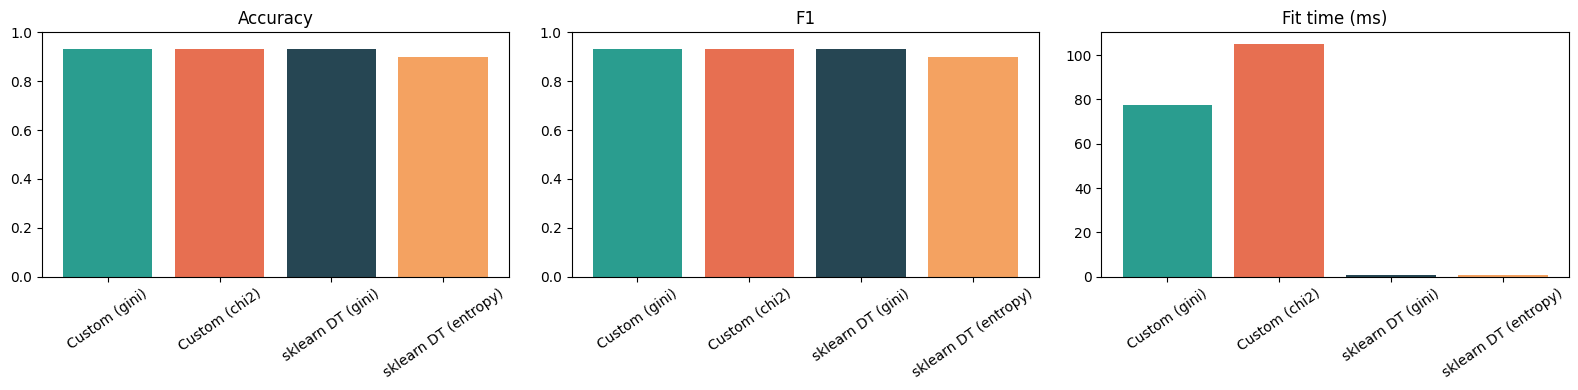

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

order = results["model"].tolist()
metrics_to_plot = ["accuracy", "f1", "fit_time_ms"]
titles = ["Accuracy", "F1", "Fit time (ms)"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals = results.set_index("model").loc[order, metric]
    ax.bar(order, vals, color=['#2A9D8F', '#E76F51', '#264653', '#F4A261'])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
    if metric in {"accuracy", "f1"}:
        ax.set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

In [8]:
x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

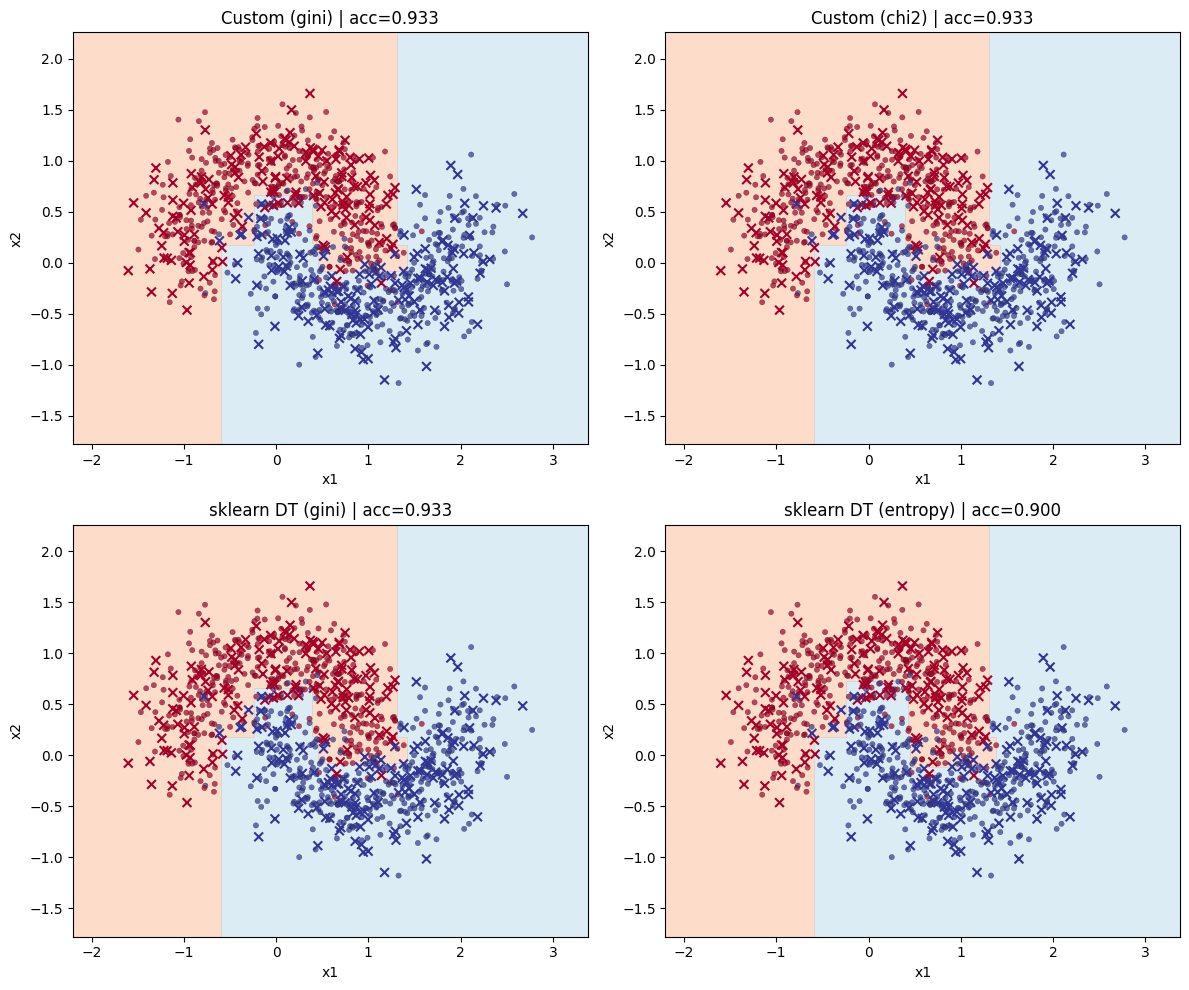

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, model_name in zip(axes, models.keys()):
    model = fitted_models[model_name]
    z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, z, alpha=0.30, levels=np.arange(-0.5, 2, 1), cmap='RdYlBu')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlBu', s=15, edgecolor='k', linewidth=0.2, alpha=0.7)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdYlBu', s=40, marker='x')

    score = results.set_index("model").loc[model_name, "accuracy"]
    ax.set_title(f"{model_name} | acc={score:.3f}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

In [10]:
results[["model", "accuracy", "f1", "fit_time_ms"]]

,model,accuracy,f1,fit_time_ms
0,Custom (gini),0.933333,0.933333,77.516792
1,Custom (chi2),0.933333,0.933333,105.055375
2,sklearn DT (gini),0.933333,0.933333,0.925333
3,sklearn DT (entropy),0.900000,0.900000,0.879583
